# Multiple run model-free hypervolume

Mean hypervolume curves for **Scalarized UCB** and **Scalarized Knowledge Gradient (KG)** across **10 independent runs**. Each experiment has separate **RTS** and **STR** figures for the holistic and Cheetah reductionist approaches.

Each line is the arithmetic mean at a checkpoint. The shaded area is **mean ? one sample standard deviation** across the ten runs (`ddof=1`), showing variability between independent runs. Checkpoints are **5, 10, ?, 150**; no smoothing, interpolation of missing checkpoints, or cumulative maximum is applied.

The completed data come from `../Model-free experiments/model_free_results.pkl`. All labels, reference points, and statistics use the settings embedded in that result file. Training seeds are 42?51, paired across methods and conditions. The two held-out realizations per sequence are separate from the ten independent algorithm runs.

Both algorithms use **7 arms**, **7 scalarization directions**, **150 online requests**, and simulated OU rewards. The dotted lines mark the end of UCB initialization at **49** requests and KG initialization at **98** requests.

| Approach | Held-out sequence horizon | Overhead reference (KiB) | Instability reference |
|---|---:|---:|---:|
| Holistic | 100 | 2,200,000 | 310 |
| Cheetah reductionist | 50 | 90,497.578125 | 85 |

The original single-run figures are preserved in [Single run model-free hypervolume](<Single run model-free hypervolume.ipynb>).


In [1]:
from pathlib import Path
import hashlib
import json
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import Markdown, display

root = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "Model-free experiments" / "model_free_results.pkl").is_file()), None)
if root is None:
    raise FileNotFoundError("Open this notebook from the Cosmic Octopi project.")
result_path = root / "Model-free experiments" / "model_free_results.pkl"
with result_path.open("rb") as file:
    bundle = pickle.load(file)
if bundle.get("kind") != "model_free_suite" or not bundle.get("complete"):
    raise ValueError("The model-free batch must be complete before plotting.")

config = bundle["setup"]
n_runs = config["n_independent_runs"]
if n_runs != 10:
    raise ValueError(f"Expected the completed ten-run experiment, got {n_runs}.")
algorithms = ("UCB", "KG")
approaches = ("holistic", "reductionist")
experiments = ("gravity", "heterogeneity", "synchronization")
formulations = ("RTS", "STR")
horizon = config["common_bandit"]["n_online_iterations"]
interval = config["evaluation"]["checkpoint_every"]
checkpoints = np.array(sorted(set(range(interval, horizon + 1, interval)) | {horizon}))
seeds = [config["base_seed"] + i * config["seed_increment"] for i in range(n_runs)]
if len(set(seeds)) != n_runs:
    raise ValueError("Independent runs must have distinct training seeds.")
expected_keys = {
    f"run_{i:02d}_seed_{seed}/{algorithm}/{approach}/{experiment}"
    for i, seed in enumerate(seeds, 1)
    for algorithm in algorithms for approach in approaches for experiment in experiments
}
if set(bundle["experiments"]) != expected_keys:
    raise ValueError("Missing or unexpected experiment records.")
setup_digest = hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()
histories = {}
paired_seeds = {}
direction_reference = None

for i, seed in enumerate(seeds, 1):
    for approach in approaches:
        a = config["approaches"][approach]
        for experiment in experiments:
            e = config["experiments"][experiment]
            expected_curves = {
                f"{form}/{e['sweep']['parameter']}={level:g}"
                for form in formulations for level in e["sweep"]["values"]
            }
            for algorithm in algorithms:
                key = f"run_{i:02d}_seed_{seed}/{algorithm}/{approach}/{experiment}"
                record = bundle["experiments"][key]
                setup = record["setup"]
                if not record["complete"] or set(record["runs"]) != expected_curves:
                    raise ValueError(f"Incomplete experiment: {key}")
                if (record["approach"], record["experiment"]) != (approach, experiment):
                    raise ValueError(f"Mislabeled experiment: {key}")
                if (setup["seed"] != seed or setup["suite"]["independent_run"] != i
                        or setup["suite"]["n_independent_runs"] != n_runs
                        or setup["suite"]["setup_sha256"] != setup_digest):
                    raise ValueError(f"Inconsistent independent-run metadata: {key}")
                expected_bandit = {**config["common_bandit"],
                                   **config["algorithms"][algorithm]["bandit"],
                                   "arm_interval": a["arm_interval"]}
                expected_evaluation = {
                    **config["evaluation"],
                    "seed": config["evaluation_base_seed"] + (i-1) * config["evaluation_seed_increment"]
                }
                for name, expected in {
                    **config["common_setup"], **e, approach: a[approach],
                    "reference_costs": a["reference_costs"],
                    "bandit": expected_bandit, "evaluation": expected_evaluation,
                }.items():
                    if setup[name] != expected:
                        raise ValueError(f"Settings differ for {key}: {name}")
                for name, digest in record["source_sha256"].items():
                    if bundle["source_sha256"].get(name) != digest:
                        raise ValueError(f"Inconsistent source provenance: {key}, {name}")
                for name, values in config["Xi_matrices"].items():
                    np.testing.assert_array_equal(record["xi_matrices"][name], values)
                np.testing.assert_array_equal(
                    record["arms"], np.linspace(*a["arm_interval"], expected_bandit["n_arms"]))
                if direction_reference is None:
                    direction_reference = record["scalarization_directions"]
                np.testing.assert_array_equal(record["scalarization_directions"], direction_reference)

                for form in formulations:
                    for level in e["sweep"]["values"]:
                        curve_key = f"{form}/{e['sweep']['parameter']}={level:g}"
                        trajectory = record["runs"][curve_key]
                        if not trajectory["complete"]:
                            raise ValueError(f"Incomplete trajectory: {key}/{curve_key}")
                        if (trajectory["formulation"] != form
                                or trajectory["sweep_parameter"] != e["sweep"]["parameter"]
                                or trajectory["sweep_value"] != level):
                            raise ValueError(f"Mislabeled trajectory: {key}/{curve_key}")
                        np.testing.assert_array_equal(trajectory["checkpoint_iterations"], checkpoints)
                        values = np.asarray(trajectory["hypervolume_history"], dtype=float)
                        if values.shape != checkpoints.shape or not np.isfinite(values).all() or (values < 0).any():
                            raise ValueError(f"Invalid hypervolume values: {key}/{curve_key}")
                        # Confirm the plotted values correspond to the saved held-out evaluations.
                        cached = [record["evaluation_cache"][cache_key]["hypervolumes"][form]
                                  for cache_key in trajectory["evaluation_keys"]]
                        np.testing.assert_array_equal(values, cached)
                        paired_key = (i, approach, experiment, form, level)
                        simulation_seeds = (trajectory["environment_seed"], trajectory["selection_seed"])
                        if paired_key in paired_seeds and paired_seeds[paired_key] != simulation_seeds:
                            raise ValueError(f"UCB/KG seeds differ: {paired_key}")
                        paired_seeds[paired_key] = simulation_seeds
                        group = (approach, experiment, form, algorithm, level)
                        histories.setdefault(group, []).append(values)

statistics = {}
for key, values in histories.items():
    samples = np.stack(values)
    if samples.shape != (n_runs, len(checkpoints)):
        raise ValueError(f"Expected ten aligned trajectories for {key}")
    statistics[key] = {
        "samples": samples,
        "mean": samples.mean(axis=0),
        "std": samples.std(axis=0, ddof=1),
    }
assert len(statistics) == 48
display(Markdown(
    f"Loaded **{n_runs} independent runs**, **{len(expected_keys)} experiments**, "
    f"and **{len(statistics) * n_runs} trajectories**. "
    f"Each curve has **{len(checkpoints)} checkpoints**, from "
    f"iteration {checkpoints[0]} to {checkpoints[-1]}."
))


Loaded **10 independent runs**, **120 experiments**, and **480 trajectories**. Each curve has **30 checkpoints**, from iteration 5 to 150.

In [2]:
def plot_multiple_runs(approach, experiment, formulation):
    sweep = config["experiments"][experiment]["sweep"]
    # Use the same vertical scale for RTS and STR within each setting.
    groups = [statistics[(approach, experiment, form, algorithm, level)]
              for form in formulations for algorithm in algorithms for level in sweep["values"]]
    lower = min(np.min(group["mean"] - group["std"]) for group in groups)
    upper = max(np.max(group["mean"] + group["std"]) for group in groups)
    padding = max(0.005, 0.08 * (upper-lower))

    fig, ax = plt.subplots(figsize=(6, 5))
    for color, level in zip(("#1f77b4", "#ff7f0e"), sweep["values"]):
        for algorithm, linestyle, marker in (("UCB", "-", "o"), ("KG", "--", "s")):
            values = statistics[(approach, experiment, formulation, algorithm, level)]
            mean, std = values["mean"], values["std"]
            label = "Sc-" + algorithm + r", $\gamma_{\mathrm{" + sweep["symbol"] + "}} = " + f"{level:g}" + "$"
            ax.fill_between(checkpoints, mean-std, mean+std, color=color, alpha=0.13,
                            linewidth=0, zorder=1)
            ax.plot(checkpoints, mean, color=color, linestyle=linestyle, marker=marker,
                    markersize=3.5, markevery=2, linewidth=2, label=label, zorder=3)
    for algorithm in algorithms:
        b = {**config["common_bandit"], **config["algorithms"][algorithm]["bandit"]}
        initialization = b["n_arms"] * b["n_scalarization_directions"] * b.get("initial_pulls_per_pair", 1)
        ax.axvline(initialization, color="0.65", linestyle=":", linewidth=0.8, zorder=2)
    ax.set_xlabel("Global iteration" if approach == "holistic" else "Cheetah request", fontsize=14)
    ax.set_ylabel("Normalized hypervolume", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.set_xlim(0, horizon)
    ax.set_ylim(lower-padding, upper+padding)
    ax.grid(False)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()


## Gravity heterogeneity

$\gamma_{\mathrm{grav}}=1$ versus $5$, with synchronization 1 and request-rate heterogeneity 0.5.

### Holistic / RTS

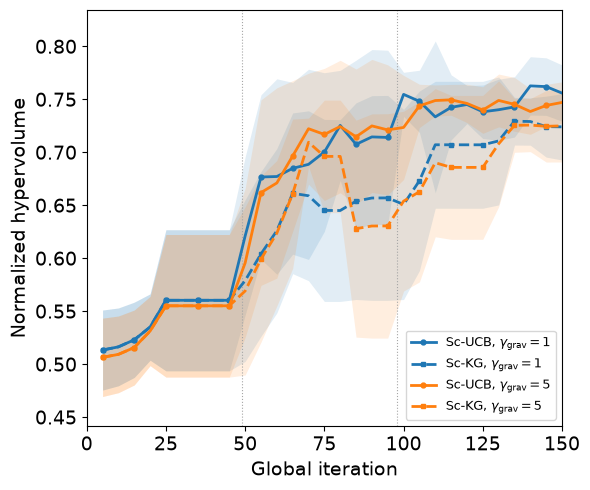

In [3]:
plot_multiple_runs("holistic", "gravity", "RTS")

### Holistic / STR

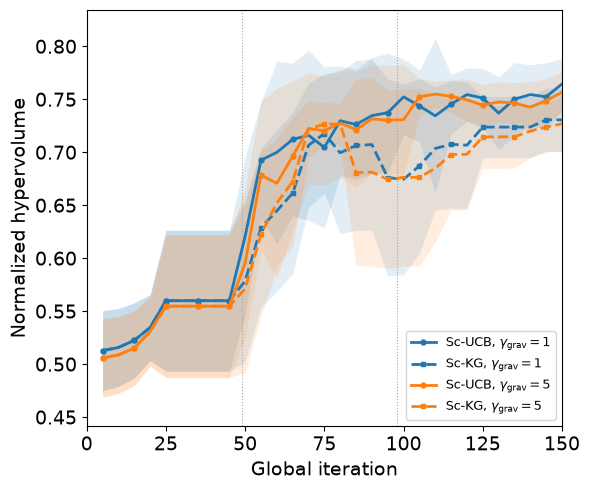

In [4]:
plot_multiple_runs("holistic", "gravity", "STR")

### Cheetah reductionist / RTS

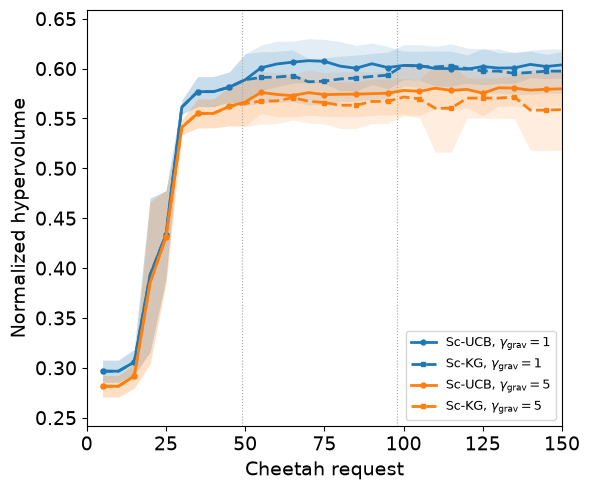

In [5]:
plot_multiple_runs("reductionist", "gravity", "RTS")

### Cheetah reductionist / STR

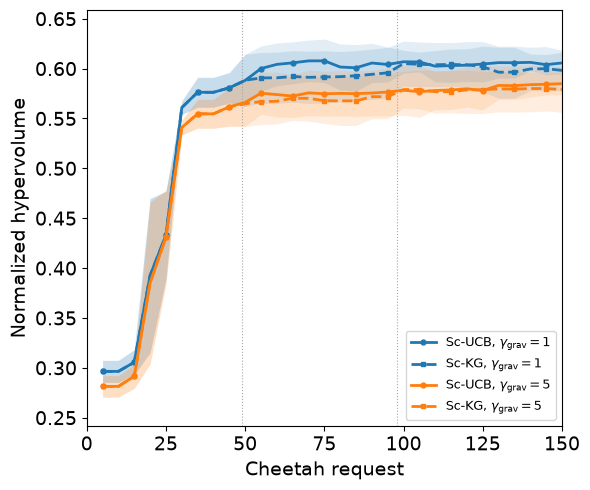

In [6]:
plot_multiple_runs("reductionist", "gravity", "STR")

## Request-rate heterogeneity

$\gamma_{\mathrm{heter}}=0.1$ versus $0.8$, with synchronization 1 and gravity variance 0.1.

### Holistic / RTS

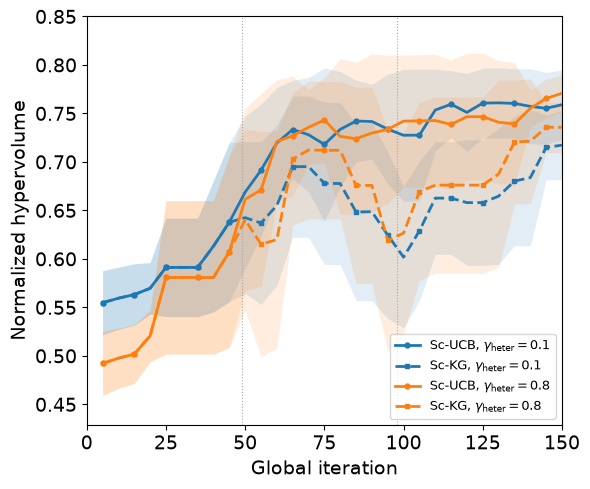

In [7]:
plot_multiple_runs("holistic", "heterogeneity", "RTS")

### Holistic / STR

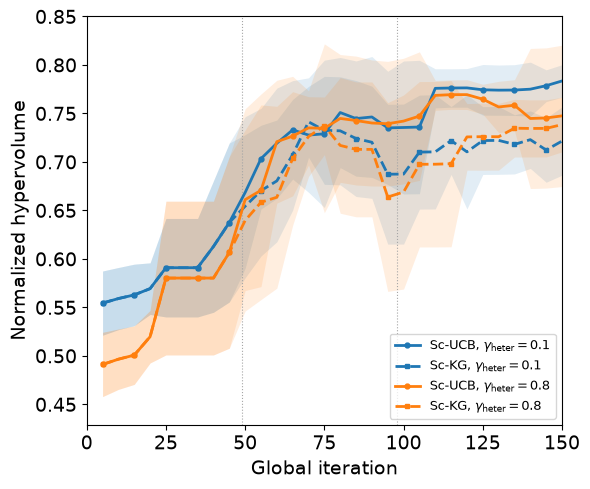

In [8]:
plot_multiple_runs("holistic", "heterogeneity", "STR")

### Cheetah reductionist / RTS

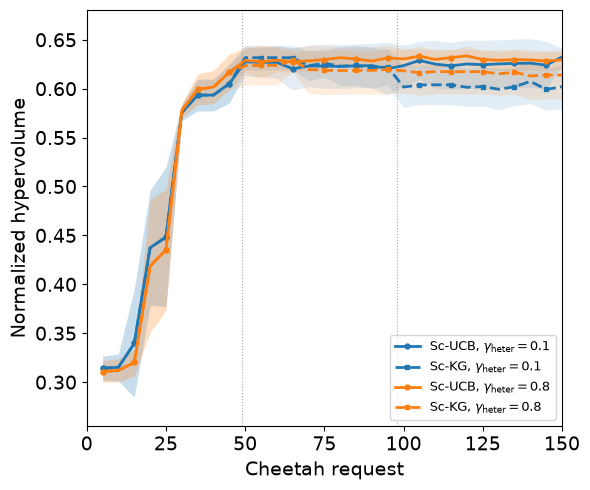

In [9]:
plot_multiple_runs("reductionist", "heterogeneity", "RTS")

### Cheetah reductionist / STR

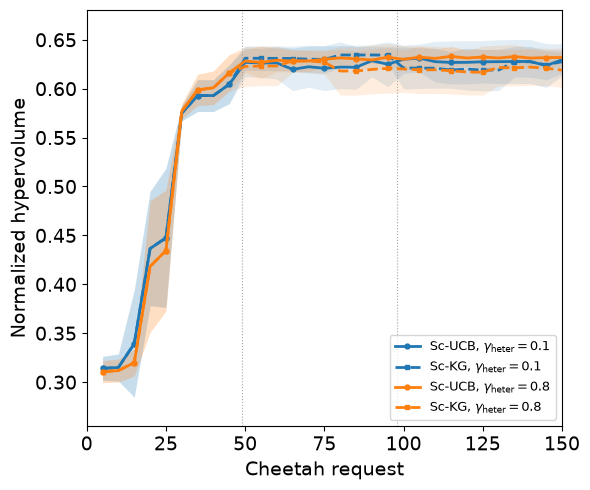

In [10]:
plot_multiple_runs("reductionist", "heterogeneity", "STR")

## Synchronization

$\gamma_{\mathrm{sync}}=1$ versus $0.8$, with gravity variance 0.1 and request-rate heterogeneity 0.5.

### Holistic / RTS

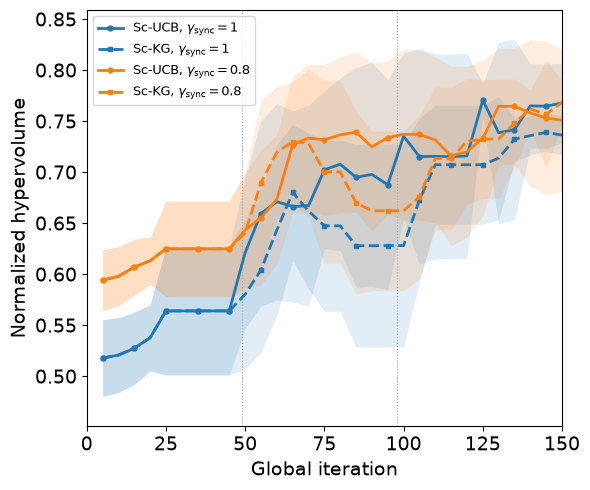

In [11]:
plot_multiple_runs("holistic", "synchronization", "RTS")

### Holistic / STR

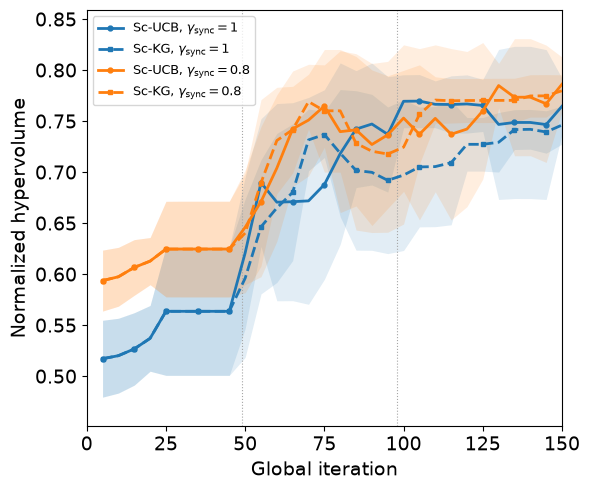

In [12]:
plot_multiple_runs("holistic", "synchronization", "STR")

### Cheetah reductionist / RTS

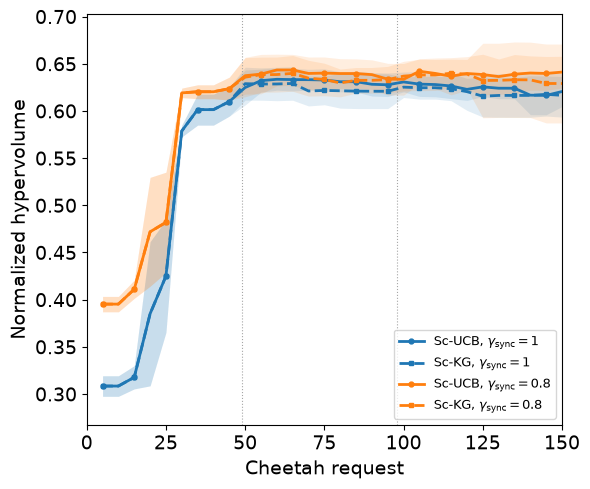

In [13]:
plot_multiple_runs("reductionist", "synchronization", "RTS")

### Cheetah reductionist / STR

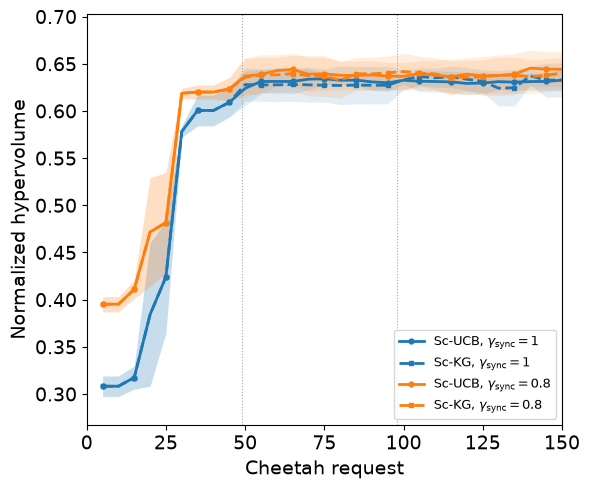

In [14]:
plot_multiple_runs("reductionist", "synchronization", "STR")

## Final hypervolume statistics

Mean and sample standard deviation across ten independent runs, at iteration 150.

In [15]:
rows = ["| Experiment | Approach | Algorithm | Formulation | Sweep value | Runs | Mean final HV | SD |",
        "|---|---|---|---|---:|---:|---:|---:|"]
for experiment in experiments:
    for approach in approaches:
        for algorithm in algorithms:
            for form in formulations:
                for level in config["experiments"][experiment]["sweep"]["values"]:
                    values = statistics[(approach, experiment, form, algorithm, level)]
                    rows.append(f"| {experiment} | {approach} | {algorithm} | {form} | {level:g} | "
                                f"{n_runs} | {values['mean'][-1]:.6f} | {values['std'][-1]:.6f} |")
display(Markdown("\n".join(rows)))


| Experiment | Approach | Algorithm | Formulation | Sweep value | Runs | Mean final HV | SD |
|---|---|---|---|---:|---:|---:|---:|
| gravity | holistic | UCB | RTS | 1 | 10 | 0.755808 | 0.026557 |
| gravity | holistic | UCB | RTS | 5 | 10 | 0.746984 | 0.019421 |
| gravity | holistic | UCB | STR | 1 | 10 | 0.764445 | 0.024085 |
| gravity | holistic | UCB | STR | 5 | 10 | 0.756497 | 0.019352 |
| gravity | holistic | KG | RTS | 1 | 10 | 0.723935 | 0.031266 |
| gravity | holistic | KG | RTS | 5 | 10 | 0.724876 | 0.034114 |
| gravity | holistic | KG | STR | 1 | 10 | 0.730568 | 0.029934 |
| gravity | holistic | KG | STR | 5 | 10 | 0.726840 | 0.025779 |
| gravity | reductionist | UCB | RTS | 1 | 10 | 0.603673 | 0.013407 |
| gravity | reductionist | UCB | RTS | 5 | 10 | 0.579732 | 0.017322 |
| gravity | reductionist | UCB | STR | 1 | 10 | 0.605615 | 0.010781 |
| gravity | reductionist | UCB | STR | 5 | 10 | 0.584879 | 0.011038 |
| gravity | reductionist | KG | RTS | 1 | 10 | 0.597469 | 0.022264 |
| gravity | reductionist | KG | RTS | 5 | 10 | 0.558893 | 0.040600 |
| gravity | reductionist | KG | STR | 1 | 10 | 0.598164 | 0.020227 |
| gravity | reductionist | KG | STR | 5 | 10 | 0.578990 | 0.022933 |
| heterogeneity | holistic | UCB | RTS | 0.1 | 10 | 0.758938 | 0.035774 |
| heterogeneity | holistic | UCB | RTS | 0.8 | 10 | 0.770719 | 0.018692 |
| heterogeneity | holistic | UCB | STR | 0.1 | 10 | 0.783440 | 0.016760 |
| heterogeneity | holistic | UCB | STR | 0.8 | 10 | 0.747452 | 0.072887 |
| heterogeneity | holistic | KG | RTS | 0.1 | 10 | 0.717271 | 0.035532 |
| heterogeneity | holistic | KG | RTS | 0.8 | 10 | 0.735633 | 0.026123 |
| heterogeneity | holistic | KG | STR | 0.1 | 10 | 0.721471 | 0.035196 |
| heterogeneity | holistic | KG | STR | 0.8 | 10 | 0.738471 | 0.028135 |
| heterogeneity | reductionist | UCB | RTS | 0.1 | 10 | 0.632254 | 0.008857 |
| heterogeneity | reductionist | UCB | RTS | 0.8 | 10 | 0.629482 | 0.010140 |
| heterogeneity | reductionist | UCB | STR | 0.1 | 10 | 0.629480 | 0.016292 |
| heterogeneity | reductionist | UCB | STR | 0.8 | 10 | 0.631852 | 0.009482 |
| heterogeneity | reductionist | KG | RTS | 0.1 | 10 | 0.601958 | 0.022758 |
| heterogeneity | reductionist | KG | RTS | 0.8 | 10 | 0.613867 | 0.024238 |
| heterogeneity | reductionist | KG | STR | 0.1 | 10 | 0.627503 | 0.012024 |
| heterogeneity | reductionist | KG | STR | 0.8 | 10 | 0.618929 | 0.017534 |
| synchronization | holistic | UCB | RTS | 1 | 10 | 0.767825 | 0.038891 |
| synchronization | holistic | UCB | RTS | 0.8 | 10 | 0.750791 | 0.069656 |
| synchronization | holistic | UCB | STR | 1 | 10 | 0.764506 | 0.027449 |
| synchronization | holistic | UCB | STR | 0.8 | 10 | 0.786109 | 0.026562 |
| synchronization | holistic | KG | RTS | 1 | 10 | 0.736202 | 0.019305 |
| synchronization | holistic | KG | RTS | 0.8 | 10 | 0.768426 | 0.021479 |
| synchronization | holistic | KG | STR | 1 | 10 | 0.746070 | 0.018681 |
| synchronization | holistic | KG | STR | 0.8 | 10 | 0.779713 | 0.015614 |
| synchronization | reductionist | UCB | RTS | 1 | 10 | 0.620552 | 0.015926 |
| synchronization | reductionist | UCB | RTS | 0.8 | 10 | 0.641150 | 0.016751 |
| synchronization | reductionist | UCB | STR | 1 | 10 | 0.632567 | 0.011338 |
| synchronization | reductionist | UCB | STR | 0.8 | 10 | 0.644116 | 0.018647 |
| synchronization | reductionist | KG | RTS | 1 | 10 | 0.616523 | 0.023051 |
| synchronization | reductionist | KG | RTS | 0.8 | 10 | 0.629064 | 0.041798 |
| synchronization | reductionist | KG | STR | 1 | 10 | 0.632786 | 0.017935 |
| synchronization | reductionist | KG | STR | 0.8 | 10 | 0.639969 | 0.016818 |